<a href="https://colab.research.google.com/github/Valedulu/greends-ml-assigment2/blob/main/aquifer_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Aquifer Petrignano Groundwater Prediction

**Goal**: Predict monthly groundwater depth (`Depth_to_Groundwater_P25`) using values from the 2 previous months.

**Main question**: Does KFold or TimeSeriesSplit give a more honest estimate of model performance?

## 1. Imports

In [1]:
# prompt: imports for data loading, preprocessing, modeling and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, TimeSeriesSplit,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import r2_score

## 0. Organize data, impute missing values, create lagged features

**Response variable**: `Depth_to_Groundwater_P25` (DP25) — groundwater depth for the target month

**Predictors**: all variables at the 2 previous months (lag1 and lag2)

Steps:
1. Load and sort chronologically
2. Resample to monthly averages
3. Impute missing values (interpolation)
4. Add seasonality variable (optional)
5. Create lagged features

In [2]:
# prompt: load CSV, parse dates, sort chronologically, resample to monthly
# Load data
df = pd.read_csv('Petrignano.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape  : {df.shape}')
print(f'Date range     : {df.Date.min()} to {df.Date.max()}')
print(f'Missing values :\n{df.isnull().sum()}')

Dataset shape  : (4199, 7)
Date range     : 2009-01-01 00:00:00 to 2020-06-30 00:00:00
Missing values :
Date                                     0
Rainfall_Bastia_Umbra                    0
Depth_to_Groundwater_P25                27
Temperature_Bastia_Umbra                 0
Temperature_Petrignano                   0
Volume_C10_Petrignano                    1
Hydrometry_Fiume_Chiascio_Petrignano     0
dtype: int64


In [5]:
# prompt: resample to monthly, impute missing values with linear interpolation
# Resample to monthly averages
df_monthly = df.set_index('Date').resample('MS').mean().reset_index()

# Imputation: fill missing values using linear interpolation
# Linear interpolation estimates missing values based on neighboring values
df_monthly = df_monthly.interpolate(method='linear')

print(f'Monthly shape  : {df_monthly.shape}')
print(f'Missing after imputation:\n{df_monthly.isnull().sum()}')
df_monthly.head()

Monthly shape  : (138, 7)
Missing after imputation:
Date                                    0
Rainfall_Bastia_Umbra                   0
Depth_to_Groundwater_P25                0
Temperature_Bastia_Umbra                0
Temperature_Petrignano                  0
Volume_C10_Petrignano                   0
Hydrometry_Fiume_Chiascio_Petrignano    0
dtype: int64


,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,2009-01-01,0.203226,-30.503871,4.964516,4.945161,-26695.119484,2.387097
1,2009-02-01,0.500000,-29.350000,5.125000,4.792857,-25641.174857,2.546429
2,2009-03-01,1.103226,-28.502903,9.254839,8.716129,-28374.874839,2.490323
3,2009-04-01,0.543333,-27.736333,13.806667,13.250000,-28167.667200,2.403333
4,2009-05-01,0.922581,-27.478065,19.809677,18.812903,-32187.288774,2.109677


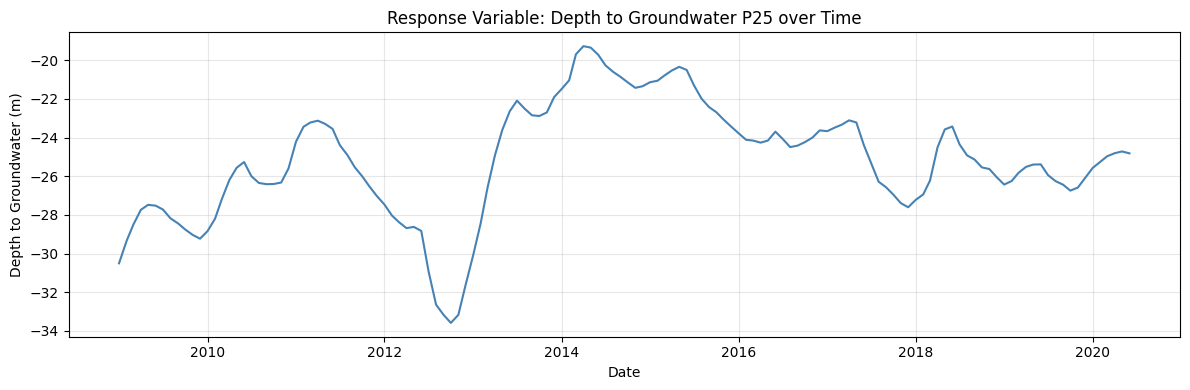

In [6]:
# Quick look at the response variable over time
plt.figure(figsize=(12, 4))
plt.plot(df_monthly['Date'], df_monthly['Depth_to_Groundwater_P25'], color='steelblue', lw=1.5)
plt.xlabel('Date'); plt.ylabel('Depth to Groundwater (m)')
plt.title('Response Variable: Depth to Groundwater P25 over Time')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [7]:
# prompt: add seasonality variable and create lagged features for 2 months
# Add seasonality variable — captures the annual cycle
# We use sin and cos of month so December and January are close together
df_monthly['sin_month'] = np.sin(2 * np.pi * df_monthly['Date'].dt.month / 12)
df_monthly['cos_month'] = np.cos(2 * np.pi * df_monthly['Date'].dt.month / 12)

# All columns to use as predictors (including DP25 itself)
feature_cols = [
    'Rainfall_Bastia_Umbra',
    'Depth_to_Groundwater_P25',
    'Temperature_Bastia_Umbra',
    'Temperature_Petrignano',
    'Volume_C10_Petrignano',
    'Hydrometry_Fiume_Chiascio_Petrignano',
    'sin_month', 'cos_month'
]

# Create lagged features: for each month i, use values from months i-1 and i-2
rows = []
for i in range(2, len(df_monthly)):
    row = {}
    for col in feature_cols:
        row[f'{col}_lag1'] = df_monthly[col].iloc[i-1]  # previous month
        row[f'{col}_lag2'] = df_monthly[col].iloc[i-2]  # 2 months ago
    row['target'] = df_monthly['Depth_to_Groundwater_P25'].iloc[i]
    rows.append(row)

df_final = pd.DataFrame(rows)

# Inputs and output — sorted chronologically
X = df_final.drop('target', axis=1).values  # predictors
y = df_final['target'].values               # response variable

print(f'Predictors X : {X.shape}  ({X.shape[1]} features = 8 variables x 2 lags)')
print(f'Response   y : {y.shape}')

Predictors X : (136, 16)  (16 features = 8 variables x 2 lags)
Response   y : (136,)


## 1. The Hard Split

We split **without shuffling** (`shuffle=False`) to respect the chronological order.
The last 20% of data becomes the **independent test dataset** — the future the model has never seen.

In [8]:
# prompt: hard chronological train/test split with shuffle=False
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False preserves time order!
)

print(f'Train dataset          : {X_train_full.shape[0]} months')
print(f'Independent test dataset: {X_test.shape[0]} months (most recent data)')

Train dataset          : 108 months
Independent test dataset: 28 months (most recent data)


## 2. Define the Two CV Strategies

- **KFold (naive)**: shuffles data randomly — ignores time order → causes **data leakage**
- **TimeSeriesSplit (temporal)**: always trains on past, tests on future → **honest estimate**

In [9]:
# prompt: define KFold and TimeSeriesSplit cross-validation strategies
# Strategy 1: Naive — shuffles randomly, ignores time order
# Problem: future data leaks into training → artificially high scores
cv_naive = KFold(n_splits=5, shuffle=True, random_state=42)

# Strategy 2: Temporal — respects chronological order
# Each fold trains on past data and tests on future data
cv_temporal = TimeSeriesSplit(n_splits=5)

print('CV strategies defined.')
print('KFold     : shuffles randomly — naive approach')
print('TimeSeriesSplit: respects time order — honest approach')

CV strategies defined.
KFold     : shuffles randomly — naive approach
TimeSeriesSplit: respects time order — honest approach


## 3. Experiment with a Fixed Model

We use the same model for both strategies to isolate the effect of the CV strategy.

In [10]:
# prompt: pipeline with StandardScaler and DecisionTreeRegressor, compare cv strategies
pipe = Pipeline([
    ('scaler',     StandardScaler()),
    ('regressor',  DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Strategy 1: Naive (Shuffled)
# This reports a very high R2 because of data leakage
scores_naive = cross_val_score(pipe, X_train_full, y_train_full,
                               cv=cv_naive, scoring='r2')

# Strategy 2: Temporal (Sequential)
# This reports a lower, more honest R2
scores_temporal = cross_val_score(pipe, X_train_full, y_train_full,
                                  cv=cv_temporal, scoring='r2')

print(f'Naive CV R2    : {scores_naive.mean():.4f} (+/- {scores_naive.std():.4f})')
print(f'Temporal CV R2 : {scores_temporal.mean():.4f} (+/- {scores_temporal.std():.4f})')

# Train on all training data and test on the unseen future
pipe.fit(X_train_full, y_train_full)
final_test_r2 = r2_score(y_test, pipe.predict(X_test))
print(f'\nActual Test R2 on independent test dataset: {final_test_r2:.4f}')

Naive CV R2    : 0.9191 (+/- 0.0318)
Temporal CV R2 : -0.5172 (+/- 2.0253)

Actual Test R2 on independent test dataset: -0.4207


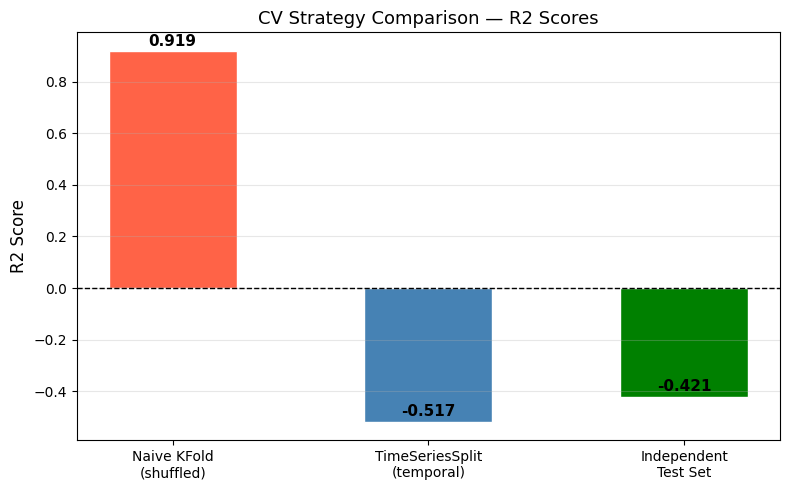


Key observation:
Naive KFold    reports R2 = 0.919 — looks great!
TimeSeriesSplit reports R2 = -0.517 — more honest
True Test R2   is    R2 = -0.421 — the real performance

Naive KFold is misleading because of DATA LEAKAGE — future data leaks into training!


In [11]:
# Visualize the difference between CV strategies
labels  = ['Naive KFold\n(shuffled)', 'TimeSeriesSplit\n(temporal)', 'Independent\nTest Set']
means   = [scores_naive.mean(), scores_temporal.mean(), final_test_r2]
colors  = ['tomato', 'steelblue', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, means, color=colors, edgecolor='white', width=0.5)
plt.axhline(0, color='black', lw=1, ls='--')
plt.ylabel('R2 Score', fontsize=12)
plt.title('CV Strategy Comparison — R2 Scores', fontsize=13)
for bar, val in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\nKey observation:')
print(f'Naive KFold    reports R2 = {scores_naive.mean():.3f} — looks great!')
print(f'TimeSeriesSplit reports R2 = {scores_temporal.mean():.3f} — more honest')
print(f'True Test R2   is    R2 = {final_test_r2:.3f} — the real performance')
print('\nNaive KFold is misleading because of DATA LEAKAGE — future data leaks into training!')

## 4. Model Selection & Evaluation

Now we run GridSearchCV with both strategies to find the best `max_depth`, and compare:
- Internal CV score (what the model thinks it achieves)
- Independent test score (what it actually achieves on unseen future data)

In [12]:
# prompt: evaluate_model_selection function with pipeline, gridsearch and final test evaluation
def evaluate_model_selection(X_train, y_train, X_test, y_test, cv_strategy, name):

    # STEP A: Define the Pipeline
    pipe = Pipeline([
        ('scaler',    StandardScaler()),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ])

    # STEP B: Define the Hyperparameter Grid
    # 'regressor__max_depth' uses the stepname__parameter syntax
    param_grid = {
        'regressor__max_depth': [2, 4, 6, 8, 10, 15, 20]  # at least 4 different depths
    }

    # STEP C: Initialize and Fit GridSearchCV
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_strategy,    # the cv strategy passed in
        scoring='r2'
    )
    grid.fit(X_train, y_train)

    # STEP D: Final Evaluation on independent test dataset
    y_pred   = grid.predict(X_test)
    test_r2  = r2_score(y_test, y_pred)

    print(f'\n===== Results for: {name} =====')
    print(f'Best hyperparameters found  : {grid.best_params_}')
    print(f'Internal CV Score (R2)      : {grid.best_score_:.4f}')
    print(f'Independent Test Score (R2) : {test_r2:.4f}')
    print(f'Gap (CV - Test)             : {grid.best_score_ - test_r2:.4f}')

    return grid

## 5. Running the Comparison

In [13]:
# prompt: run evaluate_model_selection for both cv strategies and compare results
result_naive    = evaluate_model_selection(
    X_train_full, y_train_full, X_test, y_test, cv_naive,    'Naive K-Fold'
)
result_temporal = evaluate_model_selection(
    X_train_full, y_train_full, X_test, y_test, cv_temporal, 'Temporal Split'
)


===== Results for: Naive K-Fold =====
Best hyperparameters found  : {'regressor__max_depth': 8}
Internal CV Score (R2)      : 0.9204
Independent Test Score (R2) : -0.4234
Gap (CV - Test)             : 1.3439

===== Results for: Temporal Split =====
Best hyperparameters found  : {'regressor__max_depth': 6}
Internal CV Score (R2)      : 0.1474
Independent Test Score (R2) : -0.4652
Gap (CV - Test)             : 0.6126


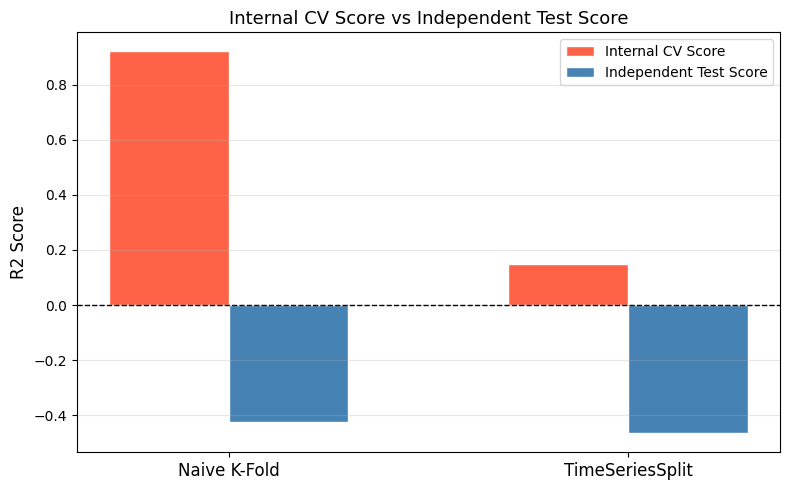


Conclusion:
Naive KFold has a large gap between CV and test score → data leakage!
TimeSeriesSplit has a smaller gap → more honest estimate of real performance


In [14]:
# Final comparison plot — internal CV score vs true test score
methods = ['Naive K-Fold', 'TimeSeriesSplit']
cv_scores   = [result_naive.best_score_,    result_temporal.best_score_]
test_scores = [
    r2_score(y_test, result_naive.predict(X_test)),
    r2_score(y_test, result_temporal.predict(X_test))
]

x = np.arange(len(methods))
width = 0.3

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, cv_scores,   width, label='Internal CV Score',         color='tomato',    edgecolor='white')
plt.bar(x + width/2, test_scores, width, label='Independent Test Score', color='steelblue', edgecolor='white')
plt.xticks(x, methods, fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.title('Internal CV Score vs Independent Test Score', fontsize=13)
plt.legend(fontsize=10)
plt.axhline(0, color='black', lw=1, ls='--')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\nConclusion:')
print('Naive KFold has a large gap between CV and test score → data leakage!')
print('TimeSeriesSplit has a smaller gap → more honest estimate of real performance')